# Assignment 3 Graph Visualization

Name: Guillermo Schneider

Dataset: Dolphins. An undirected social network of frequent associations between 62 dolphins in a community living off Doubtful Sound, New Zealand. Please cite D. Lusseau, K. Schneider, O. J. Boisseau, P. Haase, E. Slooten, and S. M. Dawson, Behavioral Ecology and Sociobiology 54, 396-405 (2003).

Interest: I just went to the Coney Island Aquarium last weekend, and really enjoyed watching the seals swim together underwater. I was surprised how social they were, and they clearly were having fun playing some kinds of "games" together, although it wasn't quite clear to me what the goals were other than a version of "tag". I've heard dolphins also are pretty smart and have large social families so picked this dataset.

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

In [13]:
#load our dolphins dataset, 
G = nx.read_gml('dolphins.gml')

We have 62 nodes, or 62 dolphins.

In [14]:
G.number_of_nodes()

62

We have 159 edges, or 159 relationships between those dolphins. Our dataset is undirected, we dont know the direction of the relationship between them.

In [24]:
G.number_of_edges()

159

Our diameter of 8 is the distance between our two furthest apart dolphins in different outer edges of the community. This suggests to me that there are some isolated dolphin groups, as 8 relationships aways in a relatively small 62 dolphin group seems like alot. Or maybe it's not, 8 away from the two farthest loner dolphins, isn't that far at all.

In [16]:
nx.diameter(G)

8

The radius of 5 is the distance from a very central dolphin to an far outer edge dolphin. This also suggests that the groups are spread out as even the most central dolphins may not interact directly with everyone.

In [25]:
nx.radius(G)

5

Looks like two big separate communities, with a few key connection dolphins between them.

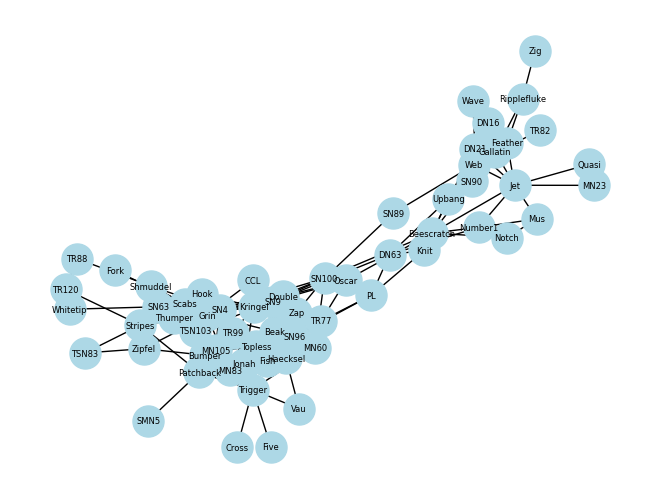

In [26]:
nx.draw(G, with_labels=True, node_color='lightblue', node_size=500, font_size=6)
plt.show()

"Betweenness centrality measures how frequently a node appears on the shortest path between other nodes in the graph". These should be dolphins that most often interact between the groups.

In [68]:
centrality = nx.betweenness_centrality(G)

These are our top 5 key connector dolphins, that everyone seems to interact with between the 2 groups:

In [108]:
k = 5 #top 5
connector_dolphins = sorted(centrality, key=centrality.get, reverse=True)[:k] #grab the top 5 from sorted centrality
print(connector_dolphins)

['SN100', 'Beescratch', 'SN9', 'SN4', 'DN63']


In [74]:
#set color to green if top 5, keep blue if not, scaled size as well
node_colors = ['green' if node in central_dolphins else 'skyblue' for node in G]
node_sizes = [1000 if node in central_dolphins else 200 for node in G]

'SN100', 'Beescratch', 'SN9', 'SN4', 'DN63' are our top 5 central dolphins connectors between the two groups.

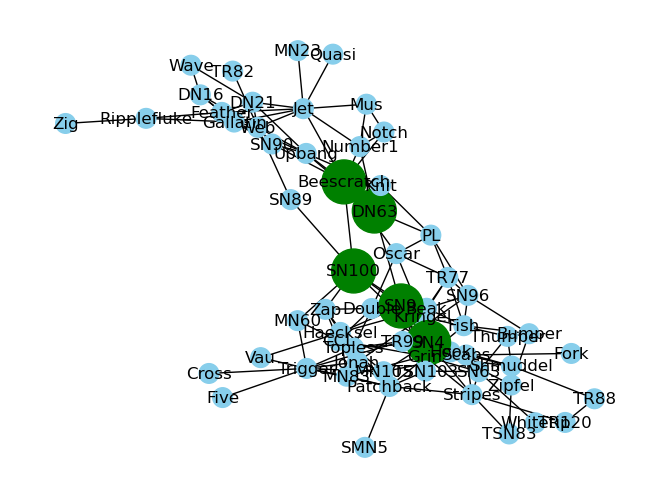

In [76]:
nx.draw(G, with_labels=True, node_color=node_colors, node_size=node_sizes)

In [101]:
k = 5 #top 5
most_connected_dolphins = dict(sorted(G.degree(), key=lambda item: item[1], reverse=True)[:k]) #sort by degrees of connection

In [105]:
print(most_connected_dolphins)

{'Grin': 12, 'SN4': 11, 'Topless': 11, 'Scabs': 10, 'Trigger': 10}


In [106]:
#set color to purple if top 5 connected, keep blue if not, scaled size as well
node_colors_2 = ['purple' if node in most_connected_dolphins else 'skyblue' for node in G]
node_sizes_2 = [1000 if node in most_connected_dolphins else 200 for node in G]

{'Grin': 12, 'SN4': 11, 'Topless': 11, 'Scabs': 10, 'Trigger': 10} all have the most relationships between all the dolphins, they also seem to be in the same group. Interestingly, this is different list than our connectors between the groups (only SN4 is both popular and connected to both groups).

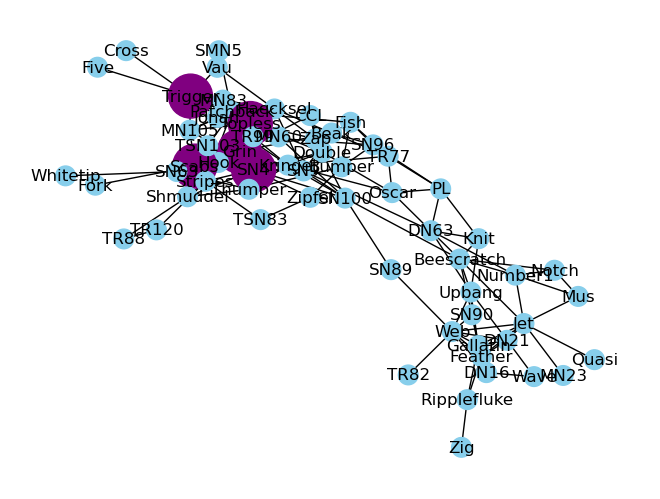

In [107]:
nx.draw(G, with_labels=True, node_color=node_colors_2, node_size=node_sizes_2)